# 모델3 : LightGBM
여러 개의 결정트리를 순차적으로 학습하며 이전 트리의 오류를 보완하는 앙상블 모델

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
PROCESSED_DIR = "/content/drive/MyDrive/Matrix/Conference2026"

X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

In [11]:
# 모델링

lgbm = LGBMClassifier(
    random_state = 42,
    n_estimators = 300,
    learning_rate = 0.05
    )
lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 43667, number of negative: 54586
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 182
[LightGBM] [Info] Number of data points in the train set: 98253, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444434 -> initscore=-0.223185
[LightGBM] [Info] Start training from score -0.223185


In [12]:
# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("="*50)
print("LightGBM Performance")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

LightGBM Performance
Accuracy : 0.7320
Precision: 0.6712
Recall   : 0.7827
F1 Score : 0.7226
ROC-AUC  : 0.8130
PR-AUC   : 0.7463

Confusion Matrix
[[9419 4208]
 [2385 8589]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.69      0.74     13627
           1       0.67      0.78      0.72     10974

    accuracy                           0.73     24601
   macro avg       0.73      0.74      0.73     24601
weighted avg       0.74      0.73      0.73     24601



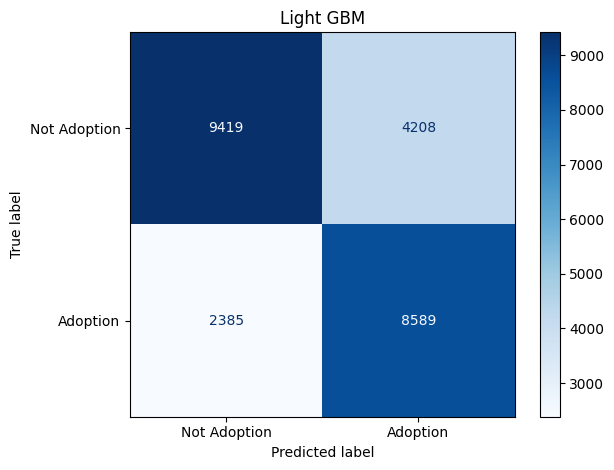

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Adoption", "Adoption"])
disp.plot(cmap="Blues")
plt.title("Light GBM")
plt.tight_layout()
plt.show()

                         feature  importance
2                       age_days        1981
3                   intake_month        1144
1                       has_name         461
9   sterilized_status_Sterilized         308
12   Intake Type_Owner Surrender         302
5         Animal Type_intake_Dog         302
20       Intake Condition_Normal         285
7                       sex_Male         271
36           breed_grouped_Other         252
4                is_repeat_visit         234
14             Intake Type_Stray         217
0                 is_mixed_breed         183
49           color_grouped_Other         172
64             intake_season_한여름         160
13     Intake Type_Public Assist         159


/tmp/ipykernel_1178/601895837.py:28: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1178/601895837.py:28: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1178/601895837.py:28: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  fig.canvas.p

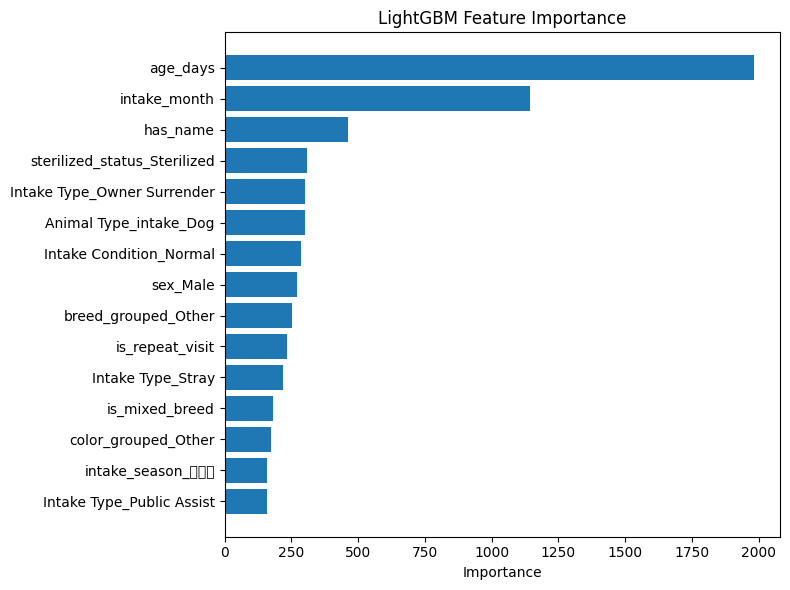

In [14]:
# 변수 중요도 (더미변수 기준)

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(15))

plt.figure(figsize=(8,6))

top15 = importance_df.head(15)

plt.barh(top15["feature"], top15["importance"])
plt.gca().invert_yaxis()

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

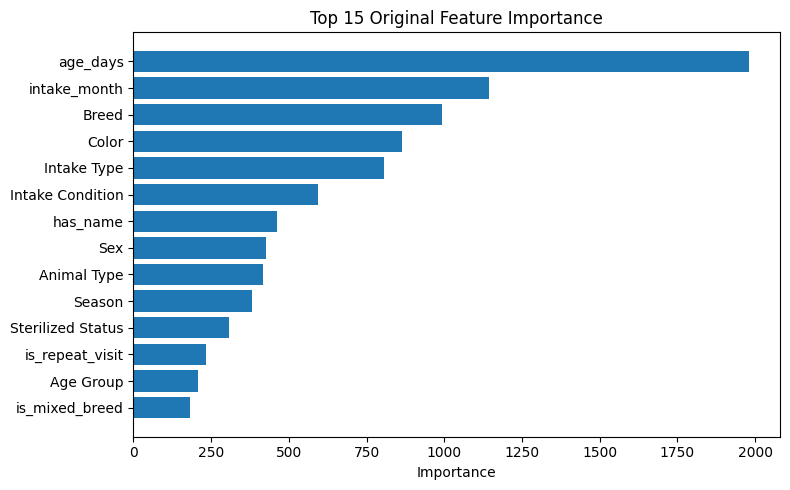

In [15]:
# 변수 중요도 (기존 변수 기준)

import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance DataFrame
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm.feature_importances_
})

plot_df = importance_df.copy()

# 변수명 매핑
mapping = {
    "Animal Type_intake_": "Animal Type",
    "sex_": "Sex",
    "sterilized_status_": "Sterilized Status",
    "Intake Type_": "Intake Type",
    "Intake Condition_": "Intake Condition",
    "breed_grouped_": "Breed",
    "color_grouped_": "Color",
    "age_group_": "Age Group",
    "intake_season_": "Season"
}

# 더미 변수 → 원래 변수명
for prefix, new_name in mapping.items():
    plot_df.loc[
        plot_df["feature"].str.startswith(prefix),
        "feature"
    ] = new_name

# 같은 변수끼리 Importance 합산
plot_df = (
    plot_df.groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

# 그래프
plt.figure(figsize=(8,5))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Original Feature Importance")
plt.tight_layout()
plt.show()

In [16]:
joblib.dump(lgbm, "/content/drive/MyDrive/Matrix/Conference2026/lgbm_model.pkl")
print("\n모델 저장 완료: lgbm_model.pkl")


모델 저장 완료: lgbm_model.pkl
